#**Name: Amsalu Tessema Adgeh**
#**ID Number: 2026A8000929002**

**Data Science Assignment-1: Data Provenance and Measurement Audit **
Github Link: https://github.com/amsalu2212

In [15]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Random seed:", SEED)

Random seed: 42


In [16]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import pandas as pd

DATA_PATH = '/content/drive/My Drive/Colab Notebooks/bankfull.csv'

df = pd.read_csv(DATA_PATH, sep=";")

print("Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [17]:
import hashlib

def sha256_file(path):
    sha256 = hashlib.sha256()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            sha256.update(chunk)

    return sha256.hexdigest()

file_hash = sha256_file(DATA_PATH)

print("File:", DATA_PATH)
print("SHA-256:", file_hash)

File: /content/drive/My Drive/Colab Notebooks/bankfull.csv
SHA-256: d1513ec63b385506f7cfce9f2c5caa9fe99e7ba4e8c3fa264b3aaf0f849ed32d


#**Research Question**

Within the UCI Bank Marketing `bankfull.csv` dataset, how does the
observed term-deposit subscription rate differ between clients contacted
by cellular telephone and clients contacted by telephone?

#**Scope**

The analysis is descriptive and associational.

It concerns observations represented in this specific dataset and does
not estimate a causal effect of communication type.

The results should not be generalized to all Portuguese bank customers,
all banking campaigns, or current banking populations.

#**Stakeholder**

The primary stakeholder is a bank marketing/CRM team interested in
understanding observed subscription patterns across communication
channels.

The stakeholder could use the analysis for descriptive campaign
monitoring, but the analysis is not sufficient by itself to establish
that changing communication channel will cause more customers to
subscribe.

# **Population**

Target population:

Clients represented by the bank marketing campaign records from which
the `bank-full.csv` dataset was constructed.

The population is not defined as all customers of the Portuguese bank,
all Portuguese adults, or all banking customers.

# **Sample**

The analytical sample consists of the 45,211 observations contained in
`bank-full.csv`, subject to the data-quality checks documented in this
notebook.

The dataset documentation states that multiple contacts may be made to
the same client. Therefore, an observation should not automatically be
interpreted as a unique person.

## **Unit of Analysis**

The unit of analysis is one campaign-record observation.

It represents a recorded marketing contact/campaign observation rather
than necessarily one unique individual.

**Define target**

The target is:y

with

yes

no

In [18]:
df["y"].value_counts(dropna=False)

,count
y,
no,39922
yes,5289


In [19]:
df["y"].value_counts(normalize=True, dropna=False)

,proportion
y,
no,0.883015
yes,0.116985


#**Define estimand**

This is an important statistics concept.

Our estimand will be:

The difference in observed subscription proportions between records contacted through cellular communication and records contacted through telephone communication within the defined dataset.

Mathematically:

$$ \theta = P(Y=1 \mid Contact=cellular) - P(Y=1 \mid Contact=telephone) $$

This is an observed association, not a causal effect.

In [20]:
#Initial dataset inspection
df.shape

(45211, 17)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [22]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [23]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [24]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,45211.0,NaN,NaN,NaN,40.93621,10.618762,18.0,33.0,39.0,48.0,95.0
job,45211,12,blue-collar,9732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,45211,3,married,27214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,45211,4,secondary,23202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,45211,2,no,44396,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balance,45211.0,NaN,NaN,NaN,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
housing,45211,2,yes,25130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,45211,2,no,37967,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,45211,3,cellular,29285,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,45211.0,NaN,NaN,NaN,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0


In [ ]:
PART 16 — Schema audit

#**Schema audit**

In [25]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null": df.notna().sum(),
    "missing": df.isna().sum(),
    "unique": df.nunique(dropna=False)
})

schema

,column,dtype,non_null,missing,unique
age,age,int64,45211,0,77
job,job,object,45211,0,12
marital,marital,object,45211,0,3
education,education,object,45211,0,4
default,default,object,45211,0,2
balance,balance,int64,45211,0,7168
housing,housing,object,45211,0,2
loan,loan,object,45211,0,2
contact,contact,object,45211,0,3
day,day,int64,45211,0,31


In [34]:
#schema.to_csv("/content/drive/My Drive/Colab Notebooks/results/schema_report.csv",

schema.to_csv(
    "/content/drive/My Drive/result/schema_report.csv",
    index=False
)

#**Check expected columns**

In [37]:
expected_columns = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "y"
]

missing_expected = set(expected_columns) - set(df.columns)
unexpected = set(df.columns) - set(expected_columns)

print("Missing expected columns:", missing_expected)
print("Unexpected columns:", unexpected)

Missing expected columns: set()
Unexpected columns: set()


#**Missingness audit**

In [38]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing.sort_values(
    "missing_percent",
    ascending=False
)

,missing_count,missing_percent
age,0,0.0
job,0,0.0
marital,0,0.0
education,0,0.0
default,0,0.0
balance,0,0.0
housing,0,0.0
loan,0,0.0
contact,0,0.0
day,0,0.0


In [39]:
# for Some missing/unknown information is represented using strings such as:
unknown_counts = {}

for col in df.select_dtypes(include="object").columns:
    unknown_counts[col] = (df[col] == "unknown").sum()

unknown_counts = pd.Series(unknown_counts).sort_values(
    ascending=False
)

unknown_counts

,0
poutcome,36959
contact,13020
education,1857
job,288
marital,0
default,0
loan,0
housing,0
month,0
y,0


The above code gives us a good measurement audit point:

Missingness may not be represented as conventional NaN; some unavailable information is encoded as "unknown".

#**Duplicate audit**

In [40]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate rows:", duplicate_count)

Exact duplicate rows: 0


In [41]:
duplicate_rate = df.duplicated().mean() * 100

print("Duplicate percentage:", duplicate_rate)

Duplicate percentage: 0.0


#**Range audit**

In [47]:
# For age
print(df["age"].min())
print(df["age"].max())


18
95


In [44]:
#For Balance
print(df["balance"].min())
print(df["balance"].max())

-8019
102127


In [48]:
#For duration:
print(df["duration"].min())
print(df["duration"].max())

0
4918


In [49]:
#For campaign
print(df["campaign"].min())
print(df["campaign"].max())

1
63


In [50]:
#For day
print(df["day"].min())
print(df["day"].max())

1
31


In [51]:
#For month
print(df["month"].unique())

['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']


#**Define explicit range checks**

In [52]:
range_checks = {
    "age_negative": (df["age"] < 0).sum(),
    "day_below_1": (df["day"] < 1).sum(),
    "day_above_31": (df["day"] > 31).sum(),
    "duration_negative": (df["duration"] < 0).sum(),
    "campaign_below_1": (df["campaign"] < 1).sum(),
    "previous_negative": (df["previous"] < 0).sum()
}

pd.Series(range_checks)

,0
age_negative,0
day_below_1,0
day_above_31,0
duration_negative,0
campaign_below_1,0
previous_negative,0


#**Category audit**

In [53]:
#This will reveal unexpected categories or "unknown" values.
categorical_columns = df.select_dtypes(
    include="object"
).columns

for col in categorical_columns:
    print("\n", "=" * 50)
    print(col)
    print(df[col].value_counts(dropna=False))


job
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

marital
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

education
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

default
default
no     44396
yes      815
Name: count, dtype: int64

housing
housing
yes    25130
no     20081
Name: count, dtype: int64

loan
loan
no     37967
yes     7244
Name: count, dtype: int64

contact
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

month
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count

#**Anomaly audit**

In [54]:
#Use statistical checks for numerical variables.
numeric_columns = df.select_dtypes(
    include=np.number
).columns

outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": count
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count
0,age,33.0,48.0,15.0,10.5,70.5,487
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729
2,day,8.0,21.0,13.0,-11.5,40.5,0
3,duration,103.0,319.0,216.0,-221.0,643.0,3235
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257
6,previous,0.0,0.0,0.0,0.0,0.0,8257


#**Leakage audit**

The variable `duration` requires special treatment.

If the intended prediction time is before or at the beginning of a
marketing call, call duration is unavailable at prediction time and
therefore represents post-contact information.

Including it in a pre-contact prediction model would create temporal
information leakage.

For the present descriptive estimand, `duration` is not required and
will not be used to define the communication-channel comparison.

In [72]:
# ==========================================
#LEAKAGE CHECK
# ==========================================

target_column = "y"

potential_post_contact_variables = [
    "duration"
]

leakage_report = pd.DataFrame({
    "variable": potential_post_contact_variables,
    "potential_leakage": [True],
    "reason": [
        "Contact duration is observed during/after the marketing contact "
        "and would not be available at the beginning of a pre-contact prediction."
    ]
})

display(leakage_report)

,variable,potential_leakage,reason
0,duration,True,Contact duration is observed during/after the ...


#**Calculate the actual estimand**
Now we answer the research question.

In [55]:
summary = (
    df.groupby("contact")["y"]
      .value_counts(normalize=True)
      .rename("proportion")
      .reset_index()
)

summary

,contact,y,proportion
0,cellular,no,0.850811
1,cellular,yes,0.149189
2,telephone,no,0.865795
3,telephone,yes,0.134205
4,unknown,no,0.959293
5,unknown,yes,0.040707


In [56]:
subscription_rates = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("contact")["subscribed"]
      .agg(["count", "mean"])
      .reset_index()
)

subscription_rates

,contact,count,mean
0,cellular,29285,0.149189
1,telephone,2906,0.134205
2,unknown,13020,0.040707


In [57]:
subscription_rates = subscription_rates.rename(
    columns={
        "count": "n",
        "mean": "subscription_rate"
    }
)

subscription_rates

,contact,n,subscription_rate
0,cellular,29285,0.149189
1,telephone,2906,0.134205
2,unknown,13020,0.040707


In [58]:
#Now we can calculate the difference:
cellular_rate = subscription_rates.loc[
    subscription_rates["contact"] == "cellular",
    "subscription_rate"
].iloc[0]

telephone_rate = subscription_rates.loc[
    subscription_rates["contact"] == "telephone",
    "subscription_rate"
].iloc[0]

difference = cellular_rate - telephone_rate

print("Cellular rate:", cellular_rate)
print("Telephone rate:", telephone_rate)
print("Difference:", difference)

Cellular rate: 0.14918900460986853
Telephone rate: 0.13420509291121818
Difference: 0.014983911698650348


#**Confidence interval**


In [60]:
# We can add a simple two-proportion confidence interval.
from statsmodels.stats.proportion import proportions_ztest
grouped = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("contact")["subscribed"]
      .agg(["sum", "count"])
)

grouped

,sum,count
contact,,
cellular,4369,29285
telephone,390,2906
unknown,530,13020


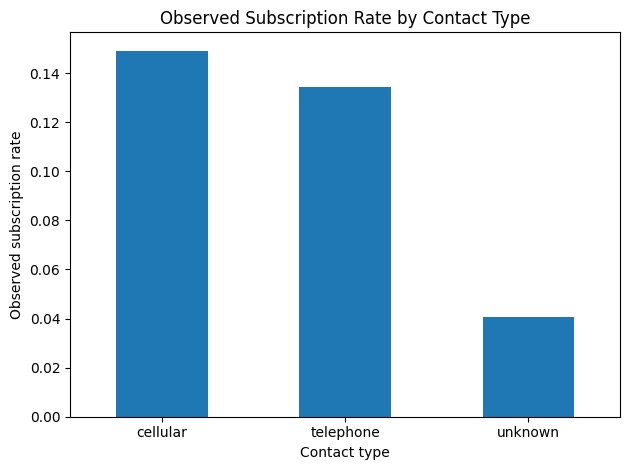

In [61]:
# Visualization
import matplotlib.pyplot as plt

plot_data = (
    df.assign(subscribed=(df["y"] == "yes").astype(int))
      .groupby("contact")["subscribed"]
      .mean()
)

plot_data.plot(kind="bar")

plt.ylabel("Observed subscription rate")
plt.xlabel("Contact type")
plt.title("Observed Subscription Rate by Contact Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
!apt-get -qq install graphviz
!pip install -q graphviz


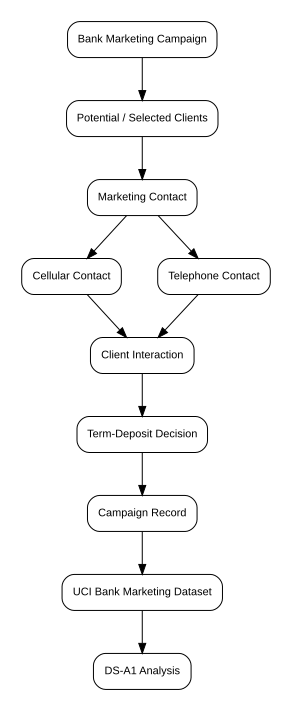

Saved to: /content/drive/My Drive/result/data_generating_process.png


In [65]:
from graphviz import Digraph
from IPython.display import display

dot = Digraph(
    "data_generating_process",
    format="png"
)

dot.attr(
    rankdir="TB",
    bgcolor="white",
    pad="0.3",
    nodesep="0.5",
    ranksep="0.6"
)

dot.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Arial",
    fontsize="11",
    margin="0.15,0.10"
)

dot.attr(
    "edge",
    fontname="Arial",
    fontsize="10"
)

# Nodes
dot.node(
    "A",
    "Bank Marketing Campaign"
)

dot.node(
    "B",
    "Potential / Selected Clients"
)

dot.node(
    "C",
    "Marketing Contact"
)

dot.node(
    "D1",
    "Cellular Contact"
)

dot.node(
    "D2",
    "Telephone Contact"
)

dot.node(
    "E",
    "Client Interaction"
)

dot.node(
    "F",
    "Term-Deposit Decision"
)

dot.node(
    "G",
    "Campaign Record"
)

dot.node(
    "H",
    "UCI Bank Marketing Dataset"
)

dot.node(
    "I",
    "DS-A1 Analysis"
)

# Connections
dot.edge("A", "B")
dot.edge("B", "C")
dot.edge("C", "D1")
dot.edge("C", "D2")
dot.edge("D1", "E")
dot.edge("D2", "E")
dot.edge("E", "F")
dot.edge("F", "G")
dot.edge("G", "H")
dot.edge("H", "I")

# Render and display
output_path = dot.render(
    "/content/drive/My Drive/result/data_generating_process",
    cleanup=True
)

display(dot)

print("Saved to:", output_path)

In [66]:
dot.format = "pdf"

pdf_path = dot.render(
    "/content/drive/My Drive/result/data_generating_process",
    cleanup=True
)

print("PDF saved to:", pdf_path)

PDF saved to: /content/drive/My Drive/result/data_generating_process.pdf


#**Provenance Lineage Diagram**




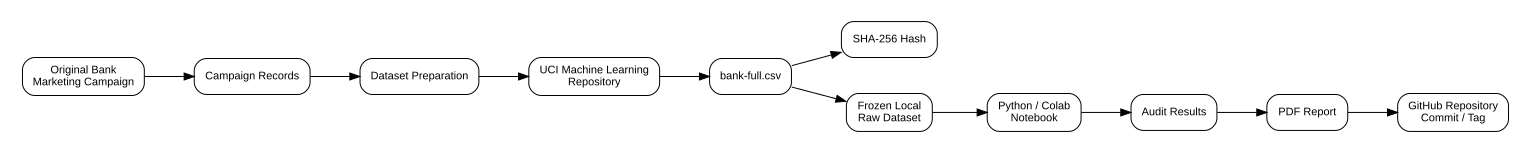

Saved to: /content/drive/My Drive/result/provenance_lineage.png


In [69]:
# Generate the provenance diagram
from graphviz import Digraph
from IPython.display import display

provenance = Digraph(
    "provenance_lineage",
    format="png"
)

provenance.attr(
    rankdir="LR",
    bgcolor="white",
    pad="0.3",
    nodesep="0.5",
    ranksep="0.7"
)

provenance.attr(
    "node",
    shape="box",
    style="rounded",
    fontname="Arial",
    fontsize="11",
    margin="0.15,0.10"
)

provenance.attr(
    "edge",
    fontname="Arial",
    fontsize="10"
)

# Nodes
provenance.node(
    "A",
    "Original Bank\nMarketing Campaign"
)

provenance.node(
    "B",
    "Campaign Records"
)

provenance.node(
    "C",
    "Dataset Preparation"
)

provenance.node(
    "D",
    "UCI Machine Learning\nRepository"
)

provenance.node(
    "E",
    "bank-full.csv"
)

provenance.node(
    "F",
    "SHA-256 Hash"
)

provenance.node(
    "G",
    "Frozen Local\nRaw Dataset"
)

provenance.node(
    "H",
    "Python / Colab\nNotebook"
)

provenance.node(
    "I",
    "Audit Results"
)

provenance.node(
    "J",
    "PDF Report"
)

provenance.node(
    "K",
    "GitHub Repository\nCommit / Tag"
)

# Lineage connections
provenance.edge("A", "B")
provenance.edge("B", "C")
provenance.edge("C", "D")
provenance.edge("D", "E")
provenance.edge("E", "F")
provenance.edge("E", "G")
provenance.edge("G", "H")
provenance.edge("H", "I")
provenance.edge("I", "J")
provenance.edge("J", "K")

# Render and display
output_path = provenance.render(
    "/content/drive/My Drive/result/provenance_lineage",
    cleanup=True
)

display(provenance)

print("Saved to:", output_path)

In [77]:
# ==========================================
# REPRODUCIBILITY VERIFICATION
# ==========================================

import sys
import platform

print("Python version:")
print(sys.version)

print("\nPlatform:")
print(platform.platform())

print("\nPandas version:")
print(pd.__version__)

print("\nNumPy version:")
print(np.__version__)

print("\nRandom seed:")
print(SEED)

print("\nDataset shape:")
print(df.shape)

print("\nDataset SHA-256:")
print(file_hash)

Python version:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]

Platform:
Linux-6.6.122+-x86_64-with-glibc2.39

Pandas version:
2.2.3

NumPy version:
2.1.3

Random seed:
42

Dataset shape:
(45211, 17)

Dataset SHA-256:
d1513ec63b385506f7cfce9f2c5caa9fe99e7ba4e8c3fa264b3aaf0f849ed32d


**Generate schema_report**

In [81]:
# ==========================================
# SCHEMA REPORT
# ==========================================

schema_report = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "missing_count": df.isna().sum(),
    "unique_count": df.nunique(dropna=False)
})

display(schema_report)



,column,dtype,non_null_count,missing_count,unique_count
age,age,int64,45211,0,77
job,job,object,45211,0,12
marital,marital,object,45211,0,3
education,education,object,45211,0,4
default,default,object,45211,0,2
balance,balance,int64,45211,0,7168
housing,housing,object,45211,0,2
loan,loan,object,45211,0,2
contact,contact,object,45211,0,3
day,day,int64,45211,0,31


In [82]:
schema_report.to_csv(
    "/content/drive/My Drive/result/schema_report1.csv",
    index=False
)

**Generate missingness_report**

In [85]:
# ==========================================
# MISSINGNESS REPORT
# ==========================================

missingness_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (
        df.isna().mean().values * 100
    )
})

display(missingness_report)

# Save as CSV
missingness_report.to_csv(
    "/content/drive/My Drive/result/missingness_report.csv",
    index=False
)

print("Saved:" "missingness_report.csv")

,column,missing_count,missing_percent
0,age,0,0.0
1,job,0,0.0
2,marital,0,0.0
3,education,0,0.0
4,default,0,0.0
5,balance,0,0.0
6,housing,0,0.0
7,loan,0,0.0
8,contact,0,0.0
9,day,0,0.0


Saved:missingness_report.csv


**Generate duplicate_report**

In [86]:
# ==========================================
# DUPLICATE REPORT
# ==========================================

total_rows = len(df)

duplicate_count = df.duplicated().sum()

duplicate_percent = (
    duplicate_count / total_rows * 100
)

duplicate_report = pd.DataFrame({
    "metric": [
        "total_rows",
        "exact_duplicate_rows",
        "duplicate_percent"
    ],
    "value": [
        total_rows,
        duplicate_count,
        duplicate_percent
    ]
})

display(duplicate_report)

# Save as CSV
duplicate_report.to_csv(
    "/content/drive/My Drive/result/duplicate_report.csv",
    index=False
)

print("Saved: duplicate_report.csv")

,metric,value
0,total_rows,45211.0
1,exact_duplicate_rows,0.0
2,duplicate_percent,0.0


Saved: duplicate_report.csv


**Generate anomaly_report**

In [87]:
# ==========================================
# ANOMALY REPORT
# ==========================================

import numpy as np

numeric_columns = df.select_dtypes(
    include=np.number
).columns

anomaly_results = []

for column in numeric_columns:

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    outlier_percent = (
        outlier_count / len(df) * 100
    )

    anomaly_results.append({
        "variable": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_percent": outlier_percent
    })

anomaly_report = pd.DataFrame(anomaly_results)

display(anomaly_report)

# Save as CSV
anomaly_report.to_csv(
   "/content/drive/My Drive/result/anomaly_report.csv",
    index=False
)

print("Saved: anomaly_report.csv")

,variable,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,age,33.0,48.0,15.0,10.5,70.5,487,1.077171
1,balance,72.0,1428.0,1356.0,-1962.0,3462.0,4729,10.459844
2,day,8.0,21.0,13.0,-11.5,40.5,0,0.000000
3,duration,103.0,319.0,216.0,-221.0,643.0,3235,7.155338
4,campaign,1.0,3.0,2.0,-2.0,6.0,3064,6.777112
5,pdays,-1.0,-1.0,0.0,-1.0,-1.0,8257,18.263255
6,previous,0.0,0.0,0.0,0.0,0.0,8257,18.263255


Saved: anomaly_report.csv


In [89]:
# ============================================
# RANGE CHECK
# ============================================

range_results = {
    "age_below_0": (df["age"] < 0).sum(),
    "day_below_1": (df["day"] < 1).sum(),
    "day_above_31": (df["day"] > 31).sum(),
    "duration_below_0": (df["duration"] < 0).sum(),
    "campaign_below_1": (df["campaign"] < 1).sum(),
    "pdays_below_-1": (df["pdays"] < -1).sum(),
    "previous_below_0": (df["previous"] < 0).sum()
}

range_report = pd.DataFrame(
    list(range_results.items()),
    columns=["check", "violation_count"]
)

display(range_report)

# Save report
range_report.to_csv(
   "/content/drive/My Drive/result/range_report.csv",
    index=False
)

print("Saved: range_report.csv")

,check,violation_count
0,age_below_0,0
1,day_below_1,0
2,day_above_31,0
3,duration_below_0,0
4,campaign_below_1,0
5,pdays_below_-1,0
6,previous_below_0,0


Saved: range_report.csv


In [90]:
# leakage_report
# ============================================
# LEAKAGE CHECK
# ============================================

potential_post_contact_variables = ["duration"]

leakage_report = pd.DataFrame({
    "variable": potential_post_contact_variables,
    "potential_leakage": [True],
    "reason": [
        "Contact duration is observed during or after the marketing "
        "contact and would not be available at the beginning of a "
        "pre-contact prediction task."
    ]
})

display(leakage_report)

# Save report
leakage_report.to_csv(
    "/content/drive/My Drive/result/leakage_report.csv",
    index=False
)

print("Saved: leakage_report.csv")

,variable,potential_leakage,reason
0,duration,True,Contact duration is observed during or after t...


Saved: leakage_report.csv


In [91]:
# estimand_results
# ============================================
# ESTIMAND ANALYSIS
# ============================================

df_analysis = df.copy()

# Convert target to binary:
# yes = 1
# no  = 0
df_analysis["subscribed"] = (
    df_analysis["y"] == "yes"
).astype(int)

# Calculate subscription rate by contact method
estimand_table = (
    df_analysis
    .groupby("contact")["subscribed"]
    .agg(
        sample_size="count",
        subscription_rate="mean"
    )
    .reset_index()
)

# Convert rate to percentage
estimand_table["subscription_rate_percent"] = (
    estimand_table["subscription_rate"] * 100
)

display(estimand_table)

# Save report
estimand_table.to_csv(
    "/content/drive/My Drive/result/estimand_results.csv",
    index=False
)

print("Saved: estimand_results.csv")

,contact,sample_size,subscription_rate,subscription_rate_percent
0,cellular,29285,0.149189,14.918900
1,telephone,2906,0.134205,13.420509
2,unknown,13020,0.040707,4.070661


Saved: estimand_results.csv


In [92]:
# ============================================
# OBSERVED DIFFERENCE IN SUBSCRIPTION RATES
# ============================================

cellular_rate = estimand_table.loc[
    estimand_table["contact"] == "cellular",
    "subscription_rate"
].iloc[0]

telephone_rate = estimand_table.loc[
    estimand_table["contact"] == "telephone",
    "subscription_rate"
].iloc[0]

observed_difference = cellular_rate - telephone_rate

print(f"Cellular subscription rate: {cellular_rate:.4f}")
print(f"Telephone subscription rate: {telephone_rate:.4f}")
print(f"Observed difference: {observed_difference:.4f}")

print(
    f"Observed difference in percentage points: "
    f"{observed_difference * 100:.2f} percentage points"
)

Cellular subscription rate: 0.1492
Telephone subscription rate: 0.1342
Observed difference: 0.0150
Observed difference in percentage points: 1.50 percentage points
